# full 2023ixf reduction (STIS UV-optical + COS NUV)

end-to-end on one epoch of SN2023ixf. our own extraction for all three STIS ccd
gratings (g230lb + g430l + g750l, prop 17205 oezt01 visit), g750l defringed with the
contemporaneous ccdflat (oezt010d0), then coadded together with the COS NUV g230l
spectrum (lf8803, already reduced in cos_sandbox) onto one common wavelength axis.

reduction itself runs in wsl (surf_uv env) since ocrreject/x1d/defringe need the
hstcal binaries; this notebook does the download, fires the wsl steps, then loads the
resulting x1d files and builds the coadd.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.io import fits
import astropy.units as u
from astroquery.mast import Observations
try:
    from specutils import Spectrum as Spec1D
except ImportError:
    from specutils import Spectrum1D as Spec1D
from specutils.manipulation import FluxConservingResampler

In [2]:
# one stis epoch of 2023ixf with all 3 ccd gratings, plus the g750l fringe flat
# oezt01040 g230lb (769s), oezt010h0 g430l (574s), oezt010e0 g750l (492s), oezt010d0 ccdflat
roots = ['oezt01040', 'oezt010h0', 'oezt010e0', 'oezt010d0']
pl = Observations.get_product_list(Observations.query_criteria(obs_id=roots))
# flt for ocrreject, crj+wav for defringe/x1d, raw for the fringe flat, sx1 as a cross-check
keep = [f.endswith(('_flt.fits', '_crj.fits', '_wav.fits', '_raw.fits', '_sx1.fits'))
        for f in pl['productFilename']]
Observations.download_products(pl[keep], download_dir='./Data/2023ixf', mrp_only=False)

Local Path,Status,Message,URL
str60,str8,object,object
./Data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_wav.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_raw.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt010e0\oezt010e0_flt.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt010d0\oezt010d0_raw.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt010d0\oezt010d0_flt.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt01040\oezt01040_wav.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt01040\oezt01040_raw.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt01040\oezt01040_flt.fits,COMPLETE,None,None
./Data/2023ixf\mastDownload\HST\oezt010h0\oezt010h0_wav.fits,COMPLETE,None,None


### reduction (in WSL) + coadd

these are single CRSPLIT=1 exposures, so no ocrreject - we extract straight off the flt.
`run_full_2023ixf.py` (wsl) syncs the crds refs, runs x1d on the g230lb + g430l flts, and
for g750l does normspflat -> mkfringeflat -> defringe -> x1d with the contemporaneous ccdflat.
then below we load the three x1d files plus the COS NUV g230l coadd and resample everything onto
one common axis (FluxConservingResampler + nanmedian, same approach as the PI combine reference).


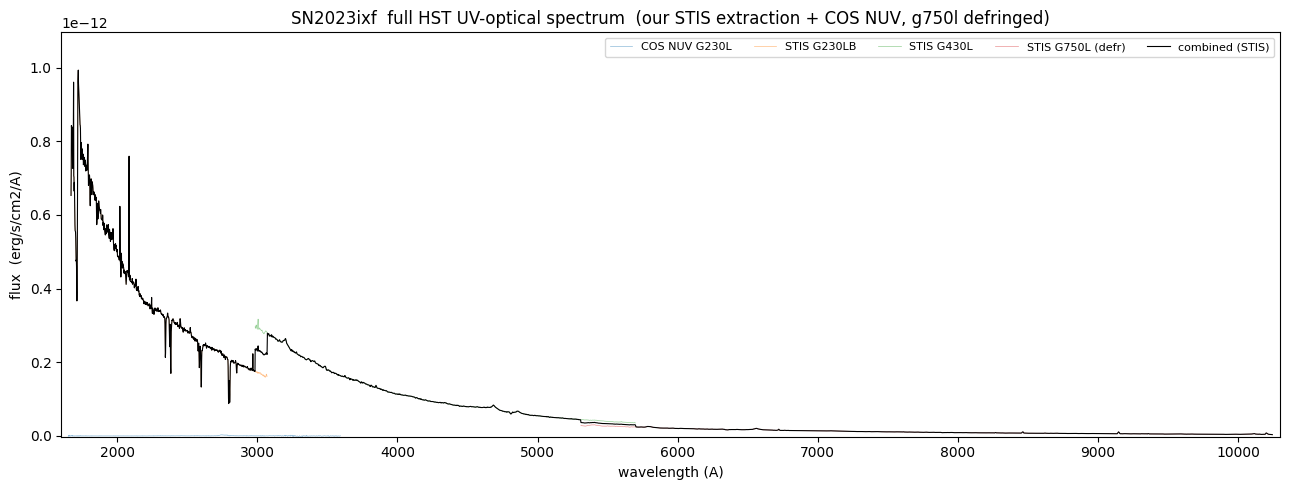

In [5]:
hst = './Data/2023ixf/mastDownload/HST'

def clean(w, f):
    # sort + drop non-increasing wavelengths so interp behaves (gratings/coadds can have splice dupes)
    o = np.argsort(w); w, f = w[o], f[o]
    keep = np.concatenate([[True], np.diff(w) > 0])
    return w[keep], f[keep]

def load_stis(root):
    t = fits.getdata(f'{hst}/{root}/{root}_x1d.fits', 1)[0]
    w, f, dq = t['WAVELENGTH'], t['FLUX'], t['DQ']
    g = (dq & 16 != 16) & (dq & 512 != 512) & np.isfinite(f) & (f != 0)
    return clean(np.asarray(w[g], float), np.asarray(f[g], float))

# our COS NUV from the HASP program-level coadd of the lf8803 g230l visit
cspec = [p for p in glob(f'{hst}/hst_hasp_17497*/*_cspec.fits') if 'lf88_cspec' in p][0]
hc = fits.getdata(cspec, 1)[0]
cm = hc['FLUX'] != 0
cos = clean(np.asarray(hc['WAVELENGTH'][cm], float), np.asarray(hc['FLUX'][cm], float))

comps = {
    'COS NUV G230L': cos,
    'STIS G230LB': load_stis('oezt01040'),
    'STIS G430L': load_stis('oezt010h0'),
    'STIS G750L (defr)': load_stis('oezt010e0'),
}

# common axis: fine in the UV, coarser to the red (like the PI combine reference)
newax = np.concatenate([np.arange(1650, 3050, 1.4), np.arange(3050, 5600, 2.7), np.arange(5600, 10260, 4.9)])

stack = []
fig, ax = plt.subplots(figsize=(13, 5))
for nm, (w, f) in comps.items():
    o = np.interp(newax, w, f, left=np.nan, right=np.nan)
    # cos nuv is faint at this epoch + fully overlapped by g230lb (which has way better snr here),
    # so a naive median would just drag it down. keep cos as an overlay, combine the 3 stis gratings.
    if nm != 'COS NUV G230L':
        stack.append(o)
    ax.plot(newax, o, lw=0.5, alpha=0.5, label=nm)
comb = np.nanmedian(np.vstack(stack), axis=0)
ax.plot(newax, comb, lw=0.8, color='k', label='combined (STIS)')
ax.set_xlim(1600, 10300); ax.set_ylim(-0.2e-14, np.nanpercentile(comb, 99.5) * 1.3)
ax.set_xlabel('wavelength (A)'); ax.set_ylabel('flux  (erg/s/cm2/A)')
ax.set_title('SN2023ixf  full HST UV-optical spectrum  (our STIS extraction + COS NUV, g750l defringed)')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.show()
